In [1]:
# ======================================================
# 🌟 LightGBM Model (Feature Eng + Outlier Removal + SMOTEENN)
# ======================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, RocCurveDisplay, precision_recall_curve
)
from lightgbm import LGBMClassifier
from imblearn.combine import SMOTEENN
import warnings
warnings.filterwarnings("ignore")


In [2]:
# ======================================================
# 📥 Load dataset v3
# ======================================================
df = pd.read_csv("../Data/final_classification_ready_v3.csv")
print("✅ Dataset loaded:", df.shape)
df.head()


✅ Dataset loaded: (40456, 23)


,MONTH,DAY_OF_MONTH,DAY_OF_WEEK,OP_UNIQUE_CARRIER,ORIGIN,DEST,CRS_DEP_TIME,CRS_ARR_TIME,CRS_ELAPSED_TIME,DISTANCE,...,HourlyVisibility,HourlyWindSpeed,DEP_DEL15,TIME_OF_DAY,TEMP_DIFF,WEATHER_SEVERITY,ROUTE,SEASON,IS_WEEKEND,IS_PEAK_HOUR
0,4,1,2,0.102778,0.060878,0.095831,15.45,18.12,160.0,1020.0,...,10.0,10.0,1.0,0.139052,12.0,6.76,0.045000,0.101124,0,0
1,4,1,2,0.102778,0.126788,0.069444,7.33,15.32,299.0,2279.0,...,10.0,6.0,0.0,0.039538,6.0,6.70,0.069444,0.101124,0,1
2,4,1,2,0.102778,0.126788,0.069444,13.83,21.83,300.0,2279.0,...,10.0,6.0,0.0,0.133490,8.0,6.58,0.069444,0.101124,0,0
3,4,1,2,0.102778,0.126788,0.069444,22.00,6.00,300.0,2279.0,...,10.0,7.0,0.0,0.158303,4.0,6.92,0.069444,0.101124,0,0
4,4,1,2,0.102778,0.126788,0.127163,5.37,11.27,234.0,1660.0,...,10.0,3.0,0.0,0.039538,4.0,6.50,0.133206,0.101124,0,0


In [3]:
# ======================================================
# ✂️ Split train/test & scale numeric features
# ======================================================
X = df.drop(columns=["DEP_DEL15"])
y = df["DEP_DEL15"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ======================================================
# ⚖️ Apply SMOTEENN (oversampling + undersampling)
# ======================================================
from imblearn.combine import SMOTEENN
smenn = SMOTEENN(random_state=42)
X_train_bal, y_train_bal = smenn.fit_resample(X_train_scaled, y_train)

print("Before:", np.bincount(y_train))
print("After :", np.bincount(y_train_bal))


Before: [28566  3798]
After : [18516 25120]


In [4]:
# ======================================================
# 🔧 Fine-tune LightGBM using GridSearchCV
# ======================================================

param_grid = {
    'num_leaves': [31, 63, 127],
    'max_depth': [5, 7, 9],
    'learning_rate': [0.05, 0.1],
    'n_estimators': [200, 400],
    'subsample': [0.7, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.9, 1.0],
    'scale_pos_weight': [1, 3, 5]
}

lgbm = LGBMClassifier(random_state=42)

grid = GridSearchCV(
    estimator=lgbm,
    param_grid=param_grid,
    scoring='f1',
    cv=3,
    n_jobs=-1,
    verbose=2
)

grid.fit(X_train_bal, y_train_bal)

print("✅ Best Parameters Found:")
print(grid.best_params_)
best_model = grid.best_estimator_


Fitting 3 folds for each of 972 candidates, totalling 2916 fits
[LightGBM] [Info] Number of positive: 25120, number of negative: 18516
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002178 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4949
[LightGBM] [Info] Number of data points in the train set: 43636, number of used features: 21
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.575671 -> initscore=0.305029
[LightGBM] [Info] Start training from score 0.305029
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[Ligh

In [5]:
# ======================================================
# 📊 Evaluate LightGBM model
# ======================================================
y_pred = best_model.predict(X_test_scaled)
y_prob = best_model.predict_proba(X_test_scaled)[:, 1]

acc = accuracy_score(y_test, y_pred)
pre = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc = roc_auc_score(y_test, y_prob)

print("📊 LightGBM (Fine-tuned + SMOTEENN) Performance:")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {pre:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-score : {f1:.4f}")
print(f"ROC-AUC  : {roc:.4f}")


📊 LightGBM (Fine-tuned + SMOTEENN) Performance:
Accuracy : 0.7984
Precision: 0.2578
Recall   : 0.3825
F1-score : 0.3080
ROC-AUC  : 0.7075


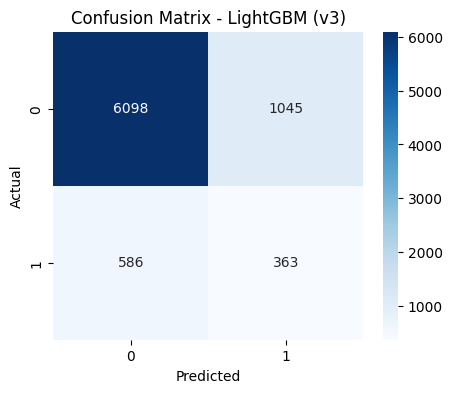

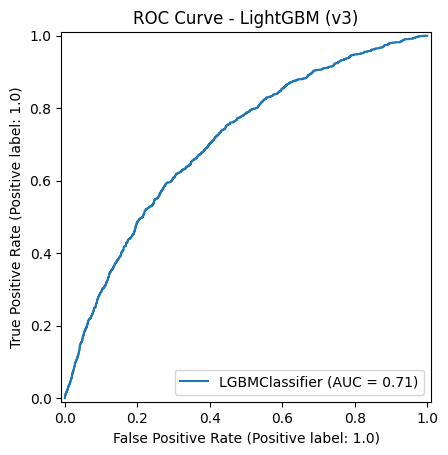

In [6]:
# ======================================================
# 📉 Visualization: Confusion Matrix & ROC
# ======================================================
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - LightGBM (v3)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ROC curve
RocCurveDisplay.from_estimator(best_model, X_test_scaled, y_test)
plt.title("ROC Curve - LightGBM (v3)")
plt.show()


In [7]:
# ======================================================
# 🧠 Find Optimal Threshold (based on F1)
# ======================================================
precision, recall, thresholds = precision_recall_curve(y_test, y_prob)
f1_scores = 2 * (precision * recall) / (precision + recall)
best_threshold = thresholds[np.argmax(f1_scores)]
print(f"✅ Best Threshold: {best_threshold:.3f}")
print(f"Best F1 at that threshold: {max(f1_scores):.4f}")

# Evaluate again with optimal threshold
y_pred_opt = (y_prob >= best_threshold).astype(int)
print("\n🔹 Evaluation with Optimal Threshold:")
print(f"Precision: {precision_score(y_test, y_pred_opt):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred_opt):.4f}")
print(f"F1-score : {f1_score(y_test, y_pred_opt):.4f}")


✅ Best Threshold: 0.391
Best F1 at that threshold: 0.3257

🔹 Evaluation with Optimal Threshold:
Precision: 0.2440
Recall   : 0.4900
F1-score : 0.3257


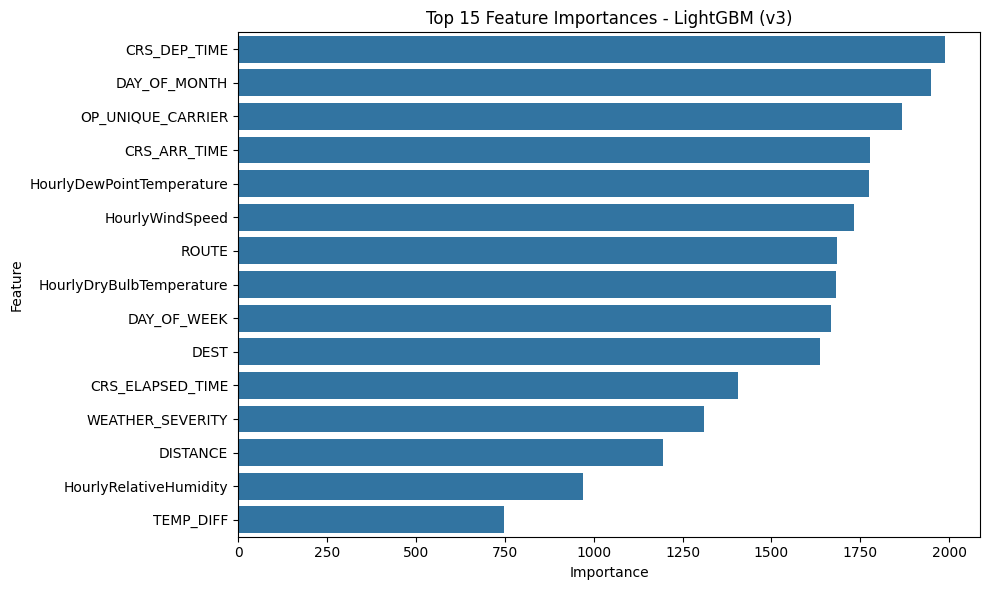

In [8]:
# ======================================================
# 🌟 Feature Importance
# ======================================================
feat_imp = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x="Importance", y="Feature", data=feat_imp.head(15))
plt.title("Top 15 Feature Importances - LightGBM (v3)")
plt.tight_layout()
plt.show()
